# DNA Fiber Assay Analysis

**Purpose:** Compare replication speed and inter-origin distance between WT and MGS variants.

**Author:** Elena Lopatukhina
**Date:** 2026-07-15

## Workflow
1. Parameters import
2. Data loading
3. Data propcessing
4. Basic statistics calculation
5. Processing outliers
6. Statistical analysis
7. Tables export
8. Graphs plot

# 1. Parameters

In [1]:
INPUT_DIR = "/mnt/c/users/helen/Desktop/110625"
OUTPUT_DIR = "/mnt/c/users/helen/Desktop/110625/results"

pixel_size = 0.16125 # µm
conversion_factor = 2.59 # kb/µm
time = 20 # minutes

# 2. Import data

## 2.1 Data loading

In [2]:
from utils import load_data, data_subset

data = load_data(dir = INPUT_DIR, pixel_size=pixel_size)

print(f"Total number of measurements for analysis is: {data.shape[0]}")

Total number of measurements for analysis is: 262


In [10]:
data

,Sample_name,File,Measurement_type,Length,ROI,Path
0,ORC1,ORC1-3aptamer_my_probe_60min_HCl_Fiber_length,Fiber_length,4.935862,0545-0998,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...
1,ORC1,ORC1-3aptamer_my_probe_60min_HCl_Fiber_length,Fiber_length,4.120583,0576-0980,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...
2,ORC1,ORC1-3aptamer_my_probe_60min_HCl_Fiber_length,Fiber_length,7.965105,0730-0891,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...
3,ORC1,ORC1-3aptamer_my_probe_60min_HCl_Fiber_length,Fiber_length,6.706871,0681-0920,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...
4,ORC1,ORC1-3aptamer_my_probe_60min_HCl_Interorigin_d...,Interorigin_distance,9.436834,0423-0639,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...
...,...,...,...,...,...,...
257,NC,NC_my_probe_60min_HCl-31_Fiber_length,Fiber_length,4.908127,0608-0367,/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...
258,NC,NC_my_probe_60min_HCl-35_Interorigin_distance,Interorigin_distance,22.975867,0223-0696,/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...
259,NC,NC_my_probe_60min_HCl-36_Interorigin_distance,Interorigin_distance,22.001595,0386-0643,/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...
260,NC,NC_my_probe_60min_HCl-36_Interorigin_distance,Interorigin_distance,33.913939,0588-0575,/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...


In [8]:
data['Sample_name'] = data['File'].apply(lambda x: x.split('-')[0] if 'ORC1' in x else x.split('_')[0])

In [ ]:
#data['Sample_name'] = data['File'].apply(lambda x: '_'.join(x.split('_')[:3]))

In [9]:
# Check sample names
data['Sample_name'].unique()

<StringArray>
['ORC1', 'NC']
Length: 2, dtype: str

### 2.2 Manually fill Sample_name column

In [ ]:
# Create Sample name column empty (custom parsing of filenames)
#data['Sample_name'] = data['File'].apply(lambda x: x.split("_")[1].split("-")[0])

#data["Sample_name"] = data["Sample_name"].apply(
#    lambda x: "WT" if "1h15min" in x else x
#)

#data["Sample_name"] = data["Sample_name"].apply(
#    lambda x: "WT" if "30min" in x else x
#)

#mask = (
#    (data["Sample_name"] == "HaloEmpty") &
#    (data["File"].str.contains("siORC1_HaloEmpty", na=False))
#)
#data.loc[mask, "Sample_name"] = "siORC1"

# Update only rows where Sample_name == "HaloEmpty" and File contains "siSCR_HaloEmpty"
#mask = (
#    (data["Sample_name"] == "HaloEmpty") &
#    (data["File"].str.contains("siSCR_HaloEmpty", na=False))
#)

#data.loc[mask, "Sample_name"] = "siSCR"

# Info about samples
#sample_names = set(data["Sample_name"])
#print(f"The amount of samples is: {len(sample_names)}.")
#print(f"There are: {sample_names}")

### 2.3 Split data into replication speed and IOD dataframe

In [11]:
speed = data_subset(df = data, measurement_type = 'Fiber_length')
print(f"The total amount of fibers measurements is: {speed.shape[0]}")

iod = data_subset(df = data, measurement_type = 'Interorigin_distance')
print(f"The total amount of IOD measurements is: {iod.shape[0]}")

The total amount of fibers measurements is: 184
The total amount of IOD measurements is: 78


### 2.4 Checking the number of measurements for each sample

#### 2.4.1 Replication speed
Divide this number by 2 because these are green and red tracks separately.

In [12]:
speed.groupby('Sample_name')['File'].count()

Sample_name
NC      88
ORC1    96
Name: File, dtype: int64

In [ ]:
# OPTIONAL
# Check analized files
#sample_name = "siSCR"
#speed[speed["Sample_name"] == sample_name]['File'].value_counts()

#### 2.4.2. IOD

In [13]:
iod.groupby('Sample_name')['File'].count()

Sample_name
NC      32
ORC1    46
Name: File, dtype: int64

In [ ]:
# OPTIONAL
# Check analized files
#sample_name = "Apt3"
#iod[iod["Sample_name"] == sample_name]['File'].value_counts()

# 3. Data processing

In [14]:
from utils import speed_processing, iod_processing

replication_speed = speed_processing(df = speed, conversion_factor = conversion_factor, time = time)
iod_kb = iod_processing(df = iod, conversion_factor = conversion_factor)

All files contain an even number of fibers.


In [15]:
replication_speed.head()

,Sample_name,File,Speed_kb_min,ROI,Path
0,NC,NC_Alessia_60min_HCl-03_Fiber_length,1.768716,"[0383-0557, 0404-0513]",/mnt/c/users/helen/Desktop/110625/NC/NC_Alessi...
1,NC,NC_Alessia_60min_HCl-03_Fiber_length,1.742592,"[0805-0518, 0833-0476]",/mnt/c/users/helen/Desktop/110625/NC/NC_Alessi...
2,NC,NC_Alessia_60min_HCl-03_Fiber_length,1.138730,"[0791-0562, 0771-0587]",/mnt/c/users/helen/Desktop/110625/NC/NC_Alessi...
3,NC,NC_Alessia_60min_HCl-04_Fiber_length,1.681910,"[0891-0629, 0914-0587]",/mnt/c/users/helen/Desktop/110625/NC/NC_Alessi...
4,NC,NC_Alessia_60min_HCl-04_Fiber_length,1.455968,"[0937-0689, 0964-0656]",/mnt/c/users/helen/Desktop/110625/NC/NC_Alessi...


In [16]:
iod_kb.head()

,Sample_name,File,IOD_kb,ROI,Path
4,ORC1,ORC1-3aptamer_my_probe_60min_HCl_Interorigin_d...,24.441399,0423-0639,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...
5,ORC1,ORC1-3aptamer_my_probe_60min_HCl_Interorigin_d...,40.329583,0343-0792,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...
6,ORC1,ORC1-3aptamer_my_probe_60min_HCl_Interorigin_d...,36.468524,0332-0841,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...
7,ORC1,ORC1-3aptamer_my_probe_60min_HCl_Interorigin_d...,46.948302,0619-1315,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...
12,ORC1,ORC1-3aptamer_my_probe_60min_HCl-02_Interorigi...,47.541347,0599-0694,/mnt/c/users/helen/Desktop/110625/Apt3/ORC1-3a...


# 4. Basic statistics calculation

In [17]:
from utils import description_stats

stats_speed = description_stats(replication_speed, col = "Speed_kb_min")
stats_iod = description_stats(iod_kb, col = "IOD_kb")

In [18]:
stats_speed

,Count,Mean,Median,SD
Sample_name,,,,
NC,44,2.432228,2.154425,0.925438
ORC1,48,1.804451,1.724718,0.521057


In [19]:
stats_iod

,Count,Mean,Median,SD
Sample_name,,,,
NC,32,70.651997,61.798656,28.027357
ORC1,46,46.335964,40.374061,19.575413


In [ ]:
#replication_speed = replication_speed[(replication_speed['Sample_name'] == 'ORC1-3_RPMI_2h') | (replication_speed['Sample_name'] == 'NC_RPMI_2h')]

In [ ]:
#iod_kb = iod_kb[(iod_kb['Sample_name'] == 'ORC1-3_RPMI_2h') | (iod_kb['Sample_name'] == 'NC_RPMI_2h')]

# 5. Processing outliers

In [20]:
from utils import outliers

speed_outliers = outliers(df = replication_speed, col = 'Speed_kb_min')
iod_outliers = outliers(df = iod_kb, col = 'IOD_kb')

In [21]:
speed_outliers

,Sample_name,File,Speed_kb_min,ROI,Path
28,NC,NC_my_probe_60min_HCl-19_Fiber_length,4.331486,"[0640-0638, 0612-0539]",/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...
29,NC,NC_my_probe_60min_HCl-19_Fiber_length,4.650331,"[0711-0858, 0672-0749]",/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...
30,NC,NC_my_probe_60min_HCl-28_Fiber_length,4.605143,"[0504-0559, 0453-0455]",/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...
31,NC,NC_my_probe_60min_HCl-28_Fiber_length,4.312629,"[0578-0704, 0624-0801]",/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...


In [22]:
iod_outliers

,Sample_name,File,IOD_kb,ROI,Path
194,NC,NC_my_probe_60min_HCl-15_Interorigin_distance,164.384208,0748-0734,/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...
216,NC,NC_my_probe_60min_HCl-18_Interorigin_distance,123.753926,0561-1021,/mnt/c/users/helen/Desktop/110625/NC/NC_my_pro...


In [ ]:
# Delete ouliers from the dataframes
speed_clean = replication_speed.drop(index=speed_outliers.index)
iod_kb_clean = iod_kb.drop(index=iod_outliers.index)

# 6. Statistical analysis
Mann-Whetney test (U-test)

In [32]:
from utils import u_test

u_speed = u_test(df = speed_clean, col = "Speed_kb_min", control_sample = "NC")
u_iod = u_test(df = iod_kb_clean, col = "IOD_kb", control_sample = "NC")

In [33]:
u_speed

,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,NC,ORC1,40,48,1311.0,0.003312


In [35]:
u_iod

,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,NC,ORC1,30,46,1060.0,0.000086


# 7. Tables export

In [36]:
from utils import table_export


# Export of tables with processed results
table_export(df = speed_clean, dir = OUTPUT_DIR, filename = "replication_speed.xlsx")
table_export(df = iod_kb_clean, dir = OUTPUT_DIR, filename = "iod_kb.xlsx")

# Export of tables with descriptive statistics
table_export(df = stats_speed, dir = OUTPUT_DIR, filename = "replication_speed_description.xlsx")
table_export(df = stats_iod, dir = OUTPUT_DIR, filename = "iod_description.xlsx")

# Export of tables with U-test analysis
table_export(df = u_speed, dir = OUTPUT_DIR, filename = "u_speed.xlsx")
table_export(df = u_iod, dir = OUTPUT_DIR, filename = "u_iod.xlsx")

# 8. Graphs with statistics

In [37]:
from plotting import boxplot_with_statistics

### 8.1 IOD graph

Plot saved to: /mnt/c/users/helen/Desktop/110625/results/IOD_kb.png


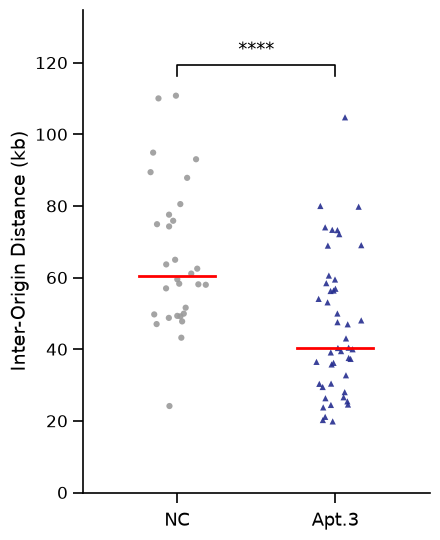

(<Figure size 450x550 with 1 Axes>,
 <Axes: ylabel='Inter-Origin Distance (kb)'>)

In [38]:
boxplot_with_statistics(
        data = iod_kb_clean,
        var = "IOD_kb",
        sample_order = ['NC', 'ORC1'],
        sample_labels = {"NC": "NC", "ORC1": "Apt.3"},
        sample_colors = {"NC": "#9a9a9a", "ORC1": "#252D8F"},
        sample_markers = {"NC": "o", "ORC1": "^"},
        figsize = (4.5, 5.5),
        stats = [
        {
                "group1": "NC",
                "group2": "ORC1",
                "p_value": 0.000086,
        }],
        y_axis = "Inter-Origin Distance (kb)",
        save_dir = OUTPUT_DIR,
        save_name = "IOD_kb",
        ext = "png"
)
        
        

### 8.2 Replication speed graph

In [ ]:
boxplot_with_statistics(
        data = replication_speed,
        var = "Speed_kb_min",
        sample_order = ['NC_RPMI_2h', 'ORC1-3_RPMI_2h'],
        sample_labels = {"NC_RPMI_2h": "NC", "ORC1-3_RPMI_2h": "Apt.3"},
        sample_colors = {"NC_RPMI_2h": "#9a9a9a", "ORC1-3_RPMI_2h": "#252D8F"},
        sample_markers = {"NC_RPMI_2h": "o", "ORC1-3_RPMI_2h": "^"},
        figsize = (4.5, 5.5),
        stats = [
        {
                "group1": "NC_RPMI_2h",
                "group2": "ORC1-3_RPMI_2h",
                "p_value": 8.287422e-07,
        }],
        y_axis = "Replication Speed (kb/min)",
        save_dir = OUTPUT_DIR,
        save_name = "Speed_kb_min",
        ext = "png"
)

Plot saved to: /mnt/c/users/helen/Desktop/110625/results/Speed_kb_min.png


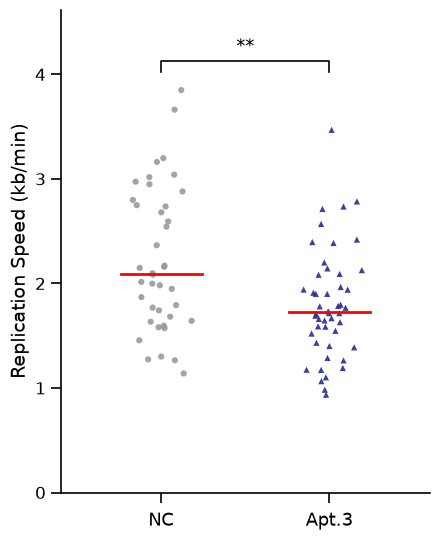

(<Figure size 450x550 with 1 Axes>,
 <Axes: ylabel='Replication Speed (kb/min)'>)

In [39]:
boxplot_with_statistics(
        data = speed_clean,
        var = "Speed_kb_min",
        sample_order = ['NC', 'ORC1'],
        sample_labels = {"NC": "NC", "ORC1": "Apt.3"},
        sample_colors = {"NC": "#9a9a9a", "ORC1": "#252D8F"},
        sample_markers = {"NC": "o", "ORC1": "^"},
        figsize = (4.5, 5.5),
        stats = [
        {
                "group1": "NC",
                "group2": "ORC1",
                "p_value": 0.003312,
        }],
        y_axis = "Replication Speed (kb/min)",
        save_dir = OUTPUT_DIR,
        save_name = "Speed_kb_min",
        ext = "png"
)